In [3]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt

In [5]:
path = os.path.abspath(os.getcwd())
file_path = os.path.join(os.path.dirname(path), "data", "employee_satisfaction.csv")

df = pd.read_csv(file_path)

df.head()

,ID_Employe,Age,Sexe,Departement,Annees_Experience,Niveau_Etudes,Salaire_Mensuel_BIF,Travail_A_Distance,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,Evaluation_Performance,Equilibre_Vie_Travail,Satisfaction_Salaire,Nombre_Absences,Satisfait
0,1,58.0,Homme,Marketing,12.0,Licence,2804177.0,Oui,13.0,95.0,8.0,0.0,3.0,Bon,Insatisfait,16.0,Oui
1,2,48.0,Femme,Marketing,NaN,Master,6000000.0,Non,12.0,48.0,10.0,4.0,1.0,Moyen,NaN,8.0,Non
2,3,34.0,Femme,Administration,16.0,NaN,4147951.0,Non,6.0,6.0,1.0,0.0,5.0,Très mauvais,Neutre,13.0,Non
3,4,27.0,Femme,Production,3.0,Licence,896874.0,Non,14.0,109.0,2.0,0.0,5.0,Moyen,Très insatisfait,16.0,Non
4,5,NaN,Femme,Administration,11.0,Master,3062453.0,Non,18.0,NaN,11.0,2.0,3.0,NaN,Très satisfait,28.0,Oui


### Dimensions, colonnes et types

In [6]:
numeric_cols = list(df.drop("ID_Employe", axis=1).select_dtypes(include=["number"]).columns)
category_cols = list(df.drop("ID_Employe", axis=1).select_dtypes(include=["object", "str"]).columns)

print(f"Colonnes dans les données : {list(df.columns)}")
print()
print(f"La forme de données du DataSet : {df.shape}")
print()
print(f"Type de données du DataSet : {df.info()}")

category_cols

Colonnes dans les données : ['ID_Employe', 'Age', 'Sexe', 'Departement', 'Annees_Experience', 'Niveau_Etudes', 'Salaire_Mensuel_BIF', 'Travail_A_Distance', 'Heures_Supplementaires', 'Heures_Formation', 'Anciennete_Entreprise', 'Nombre_Promotions', 'Evaluation_Performance', 'Equilibre_Vie_Travail', 'Satisfaction_Salaire', 'Nombre_Absences', 'Satisfait']

La forme de données du DataSet : (510, 17)

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Employe              510 non-null    int64  
 1   Age                     485 non-null    float64
 2   Sexe                    485 non-null    str    
 3   Departement             485 non-null    str    
 4   Annees_Experience       485 non-null    float64
 5   Niveau_Etudes           485 non-null    str    
 6   Salaire_Mensuel_BIF     485 non-null    float64
 7   Travail_A_Distance      

['Sexe',
 'Departement',
 'Niveau_Etudes',
 'Travail_A_Distance',
 'Equilibre_Vie_Travail',
 'Satisfaction_Salaire',
 'Satisfait']

### Premier coup d'oeil aux données

In [7]:
df.head()
df.tail()
df.sample(10)

,ID_Employe,Age,Sexe,Departement,Annees_Experience,Niveau_Etudes,Salaire_Mensuel_BIF,Travail_A_Distance,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,Evaluation_Performance,Equilibre_Vie_Travail,Satisfaction_Salaire,Nombre_Absences,Satisfait
155,156,32.0,Homme,Logistique,0.0,Secondaire,319192.0,Oui,12.0,117.0,0.0,1.0,1.0,Moyen,Neutre,3.0,Oui
62,63,33.0,Femme,Logistique,3.0,Master,1066341.0,Oui,3.0,6.0,0.0,0.0,4.0,Bon,Insatisfait,15.0,Non
317,318,NaN,Homme,Recherche et Développement,12.0,Master,3890725.0,Non,1.0,17.0,0.0,0.0,2.0,Moyen,Satisfait,6.0,Oui
288,289,53.0,Homme,Support Client,21.0,Master,3787973.0,Non,31.0,71.0,13.0,4.0,4.0,Moyen,Insatisfait,0.0,Oui
58,59,45.0,Homme,Production,16.0,Master,3369738.0,Oui,22.0,40.0,5.0,0.0,1.0,Moyen,Insatisfait,6.0,Non
466,467,60.0,Femme,Ressources Humaines,18.0,Master,4459058.0,Oui,11.0,6.0,9.0,4.0,1.0,Mauvais,Insatisfait,2.0,Oui
282,283,49.0,Homme,Ressources Humaines,16.0,Licence,3418862.0,Oui,1.0,NaN,6.0,0.0,3.0,Bon,Très insatisfait,6.0,Oui
196,197,24.0,Femme,Marketing,6.0,Secondaire,NaN,NaN,35.0,87.0,6.0,3.0,3.0,Bon,Très satisfait,20.0,Oui
69,70,40.0,Homme,Logistique,18.0,Licence,3273162.0,Oui,39.0,0.0,NaN,4.0,4.0,Moyen,Neutre,24.0,Non
481,482,55.0,NaN,Administration,NaN,Licence,3061758.0,Oui,34.0,111.0,3.0,2.0,1.0,Bon,Satisfait,28.0,Oui


### Statistiques descriptives

In [7]:
df.describe()
# df.describe(include=["object"])

,ID_Employe,Age,Annees_Experience,Salaire_Mensuel_BIF,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,Evaluation_Performance,Nombre_Absences
count,510.000000,485.000000,485.000000,4.850000e+02,485.000000,485.000000,485.000000,485.000000,485.000000,485.000000
mean,255.500000,40.896907,10.800000,2.574893e+06,19.402062,60.544330,5.350515,1.200000,2.894845,15.121649
std,147.368586,11.936890,8.879776,1.775794e+06,11.477664,34.872741,5.848008,1.390345,1.450019,8.695946
min,1.000000,20.000000,0.000000,3.005580e+05,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,128.250000,31.000000,3.000000,9.909610e+05,10.000000,30.000000,1.000000,0.000000,2.000000,8.000000
50%,255.500000,43.000000,9.000000,2.131324e+06,19.000000,58.000000,3.000000,1.000000,3.000000,15.000000
75%,382.750000,51.000000,17.000000,3.799363e+06,30.000000,91.000000,8.000000,2.000000,4.000000,23.000000
max,510.000000,60.000000,35.000000,6.000000e+06,40.000000,120.000000,27.000000,6.000000,5.000000,30.000000


### Identification de valeurs maquantes

In [8]:
df.isnull()
df.isnull().sum().sort_values(ascending=False)

Heures_Supplementaires    25
Nombre_Absences           25
Sexe                      25
Departement               25
Annees_Experience         25
Niveau_Etudes             25
Salaire_Mensuel_BIF       25
Travail_A_Distance        25
Age                       25
Heures_Formation          25
Anciennete_Entreprise     25
Nombre_Promotions         25
Evaluation_Performance    25
Equilibre_Vie_Travail     25
Satisfaction_Salaire      25
ID_Employe                 0
Satisfait                  0
dtype: int64

### Lignes en double

In [9]:
df.duplicated()
df.duplicated().sum()

np.int64(0)

### Analyse de la cible

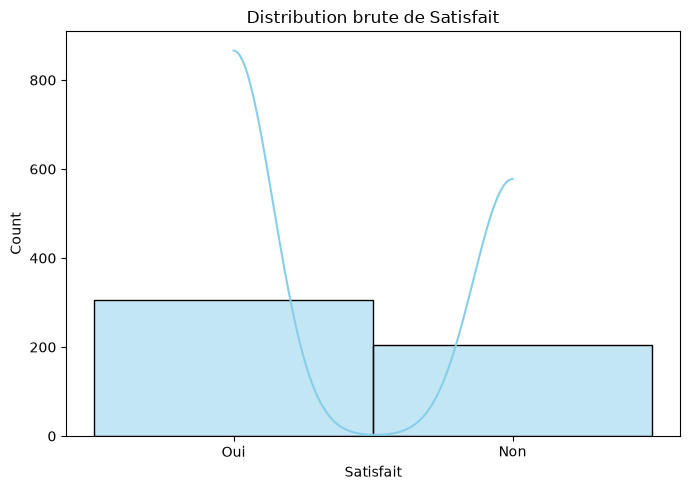

In [18]:
plt.subplots(figsize=(7, 5))

sns.histplot(df["Satisfait"], kde=True, color="skyblue")
plt.title("Distribution brute de Satisfait")

# Distribution avec Transformation Log
# sns.histplot(df["Satisfait"], kde=True, ax=axes[1], color="orange")
# axes[1].set_title("Distribution de Satisfait")

plt.tight_layout()
plt.show()

### Analyses de features numériques

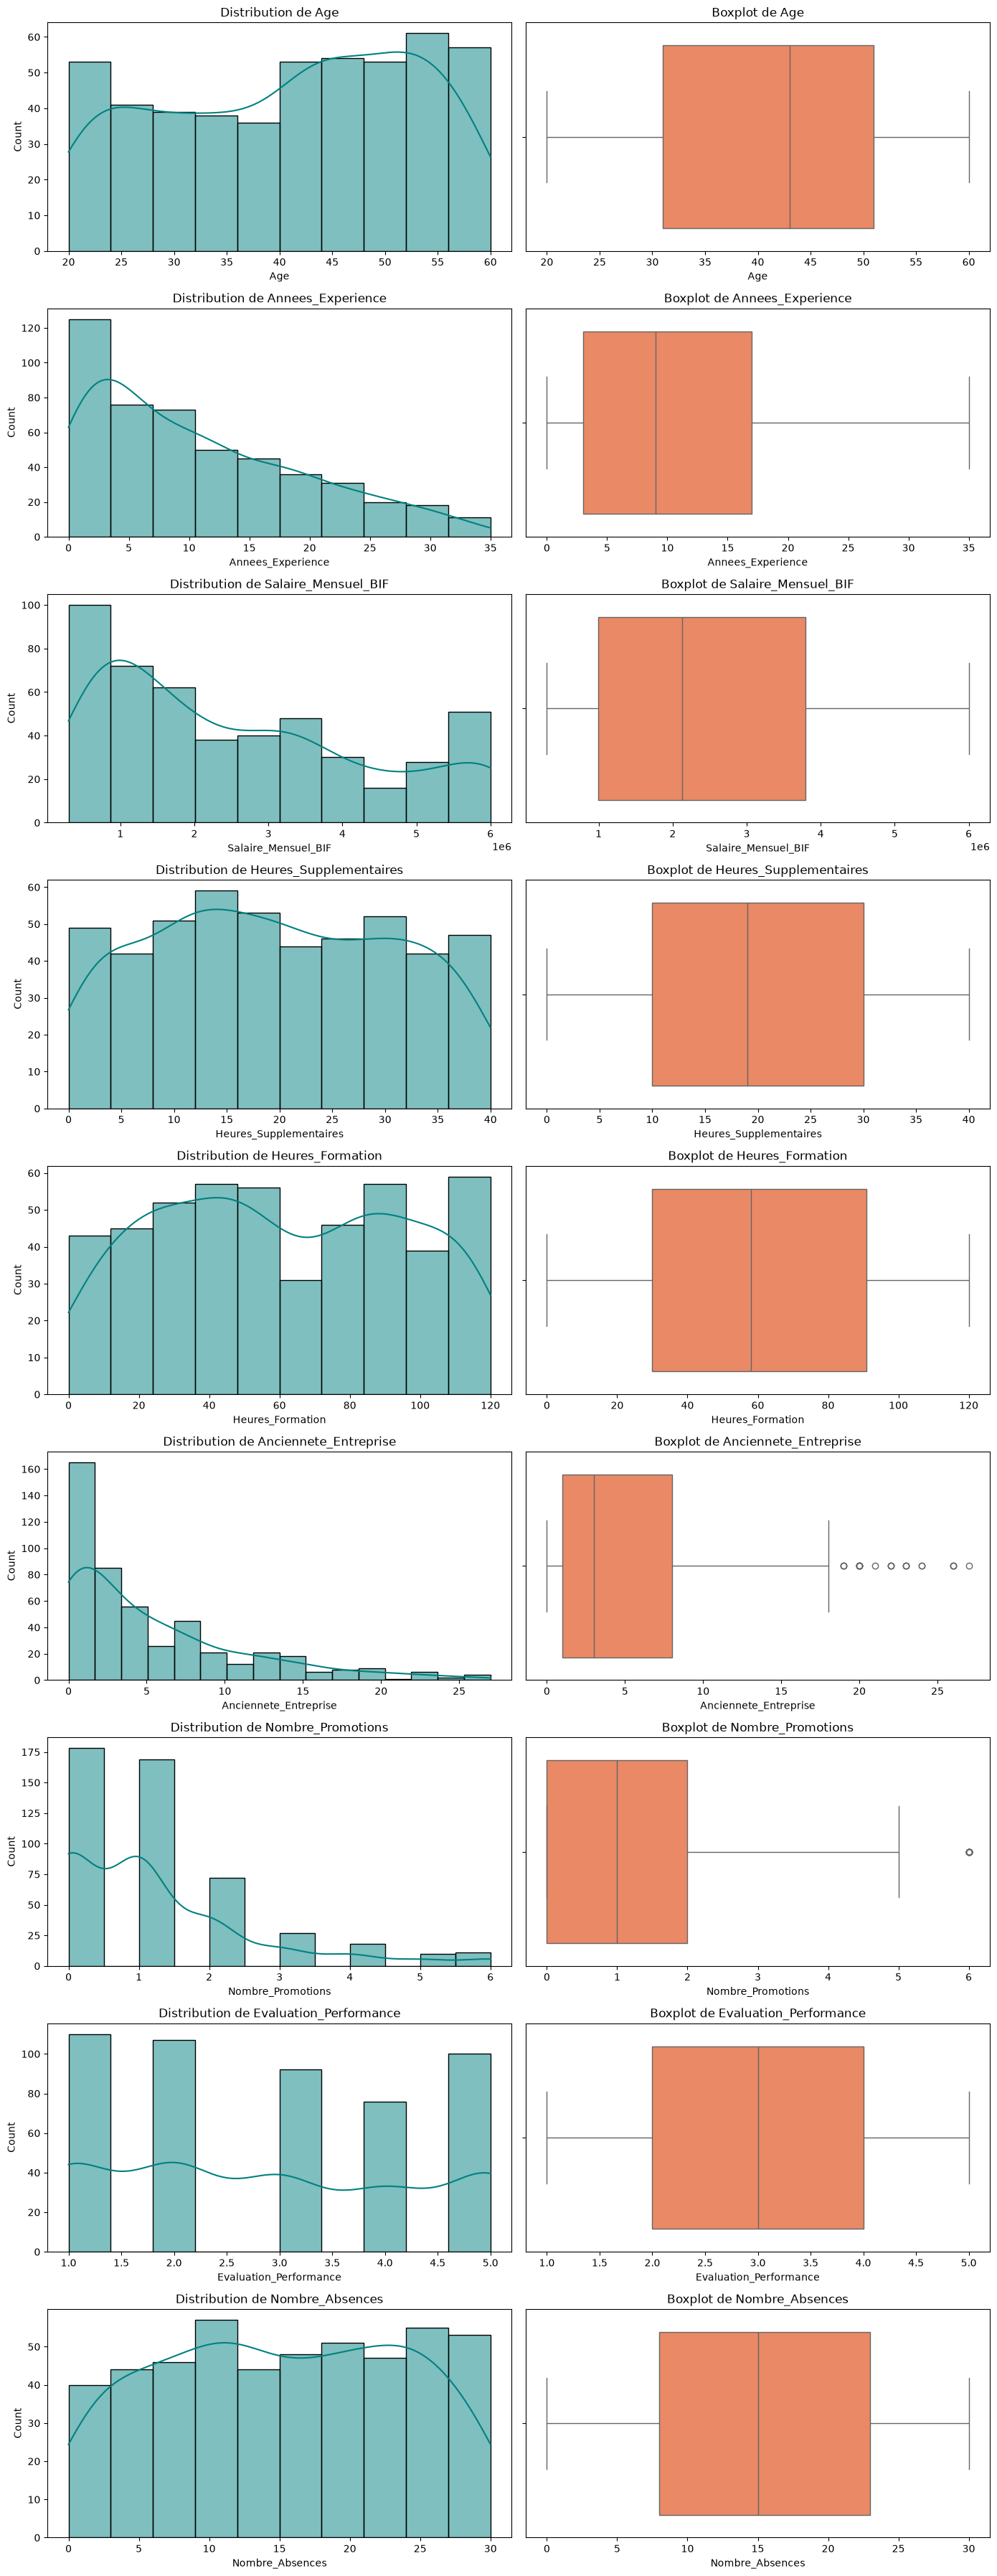

In [11]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="teal")
    axes[i, 0].set_title(f"Distribution de {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1], color="coral")
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### Analyses de variables catégorielles

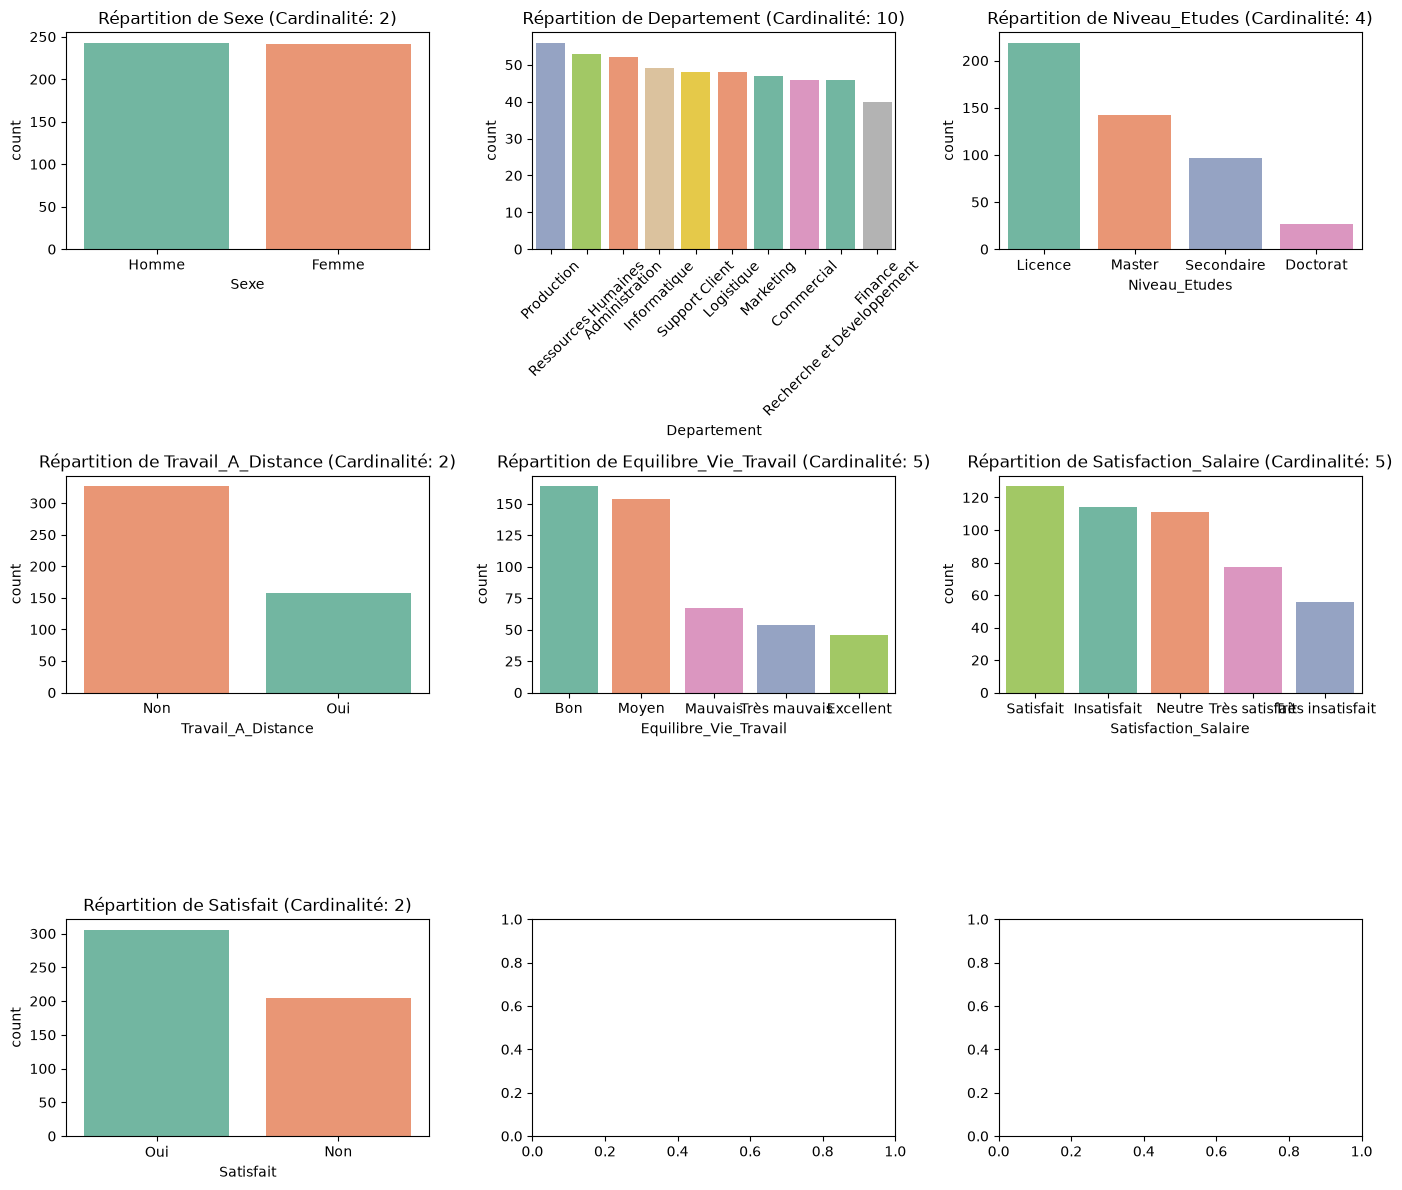

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(category_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        ax=axes[i],
        palette="Set2",
        order=df[col].value_counts().index,
    )
    axes[i].set_title(f"Répartition de {col} (Cardinalité: {df[col].nunique()})")
    axes[i].tick_params(axis="x", rotation=45 if df[col].nunique() > 5 else 0)

plt.tight_layout()
plt.show()

In [24]:
"""
  Calcule le V de Cramer entre deux variables catégorielles x et y

"""

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    # La formule de v de crammer
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in category_cols:
    corr = cramers_v(df[col], df["Satisfait"])
    print(col, "-->", corr)

Sexe --> 0.07799996702696084
Departement --> 0.0
Niveau_Etudes --> 0.0
Travail_A_Distance --> 0.12406661436647681
Equilibre_Vie_Travail --> 0.4535885988445382
Satisfaction_Salaire --> 0.46227660678634264
Satisfait --> 0.9959069748813502


### Pattern des valeurs maquantes

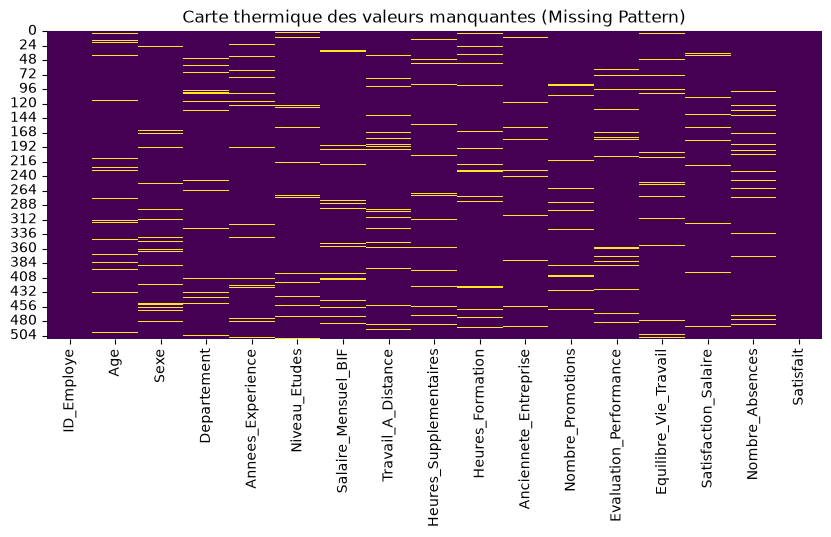

In [25]:
# Visualiser si les manques sont corrélés entre eux (MCAR vs MNAR)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Carte thermique des valeurs manquantes (Missing Pattern)")
plt.show()

### Corrélation avec la variable cible (LoyerMensuel_BIF)

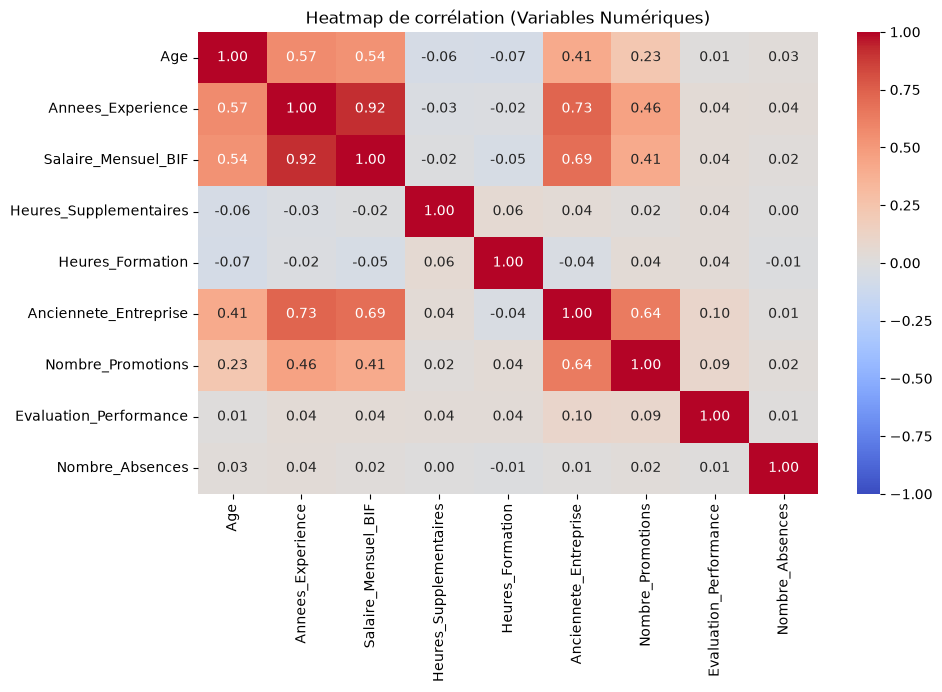

In [30]:
plt.figure(figsize=(10, 6))

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation (Variables Numériques)")
plt.show()

### Scatter plots / Boxplots croisant chaque feature avec LoyerMensuel_BIF.

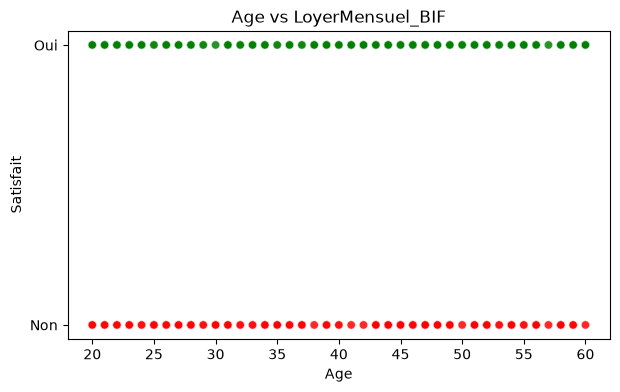

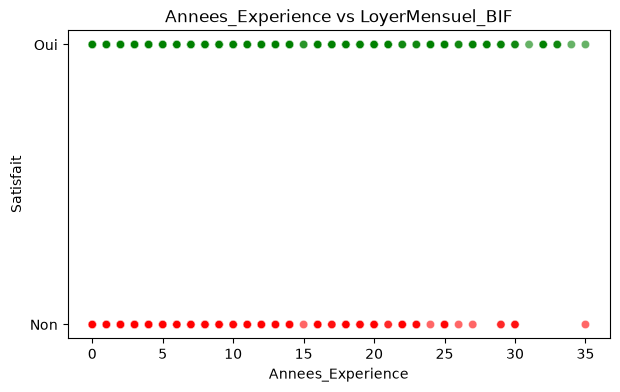

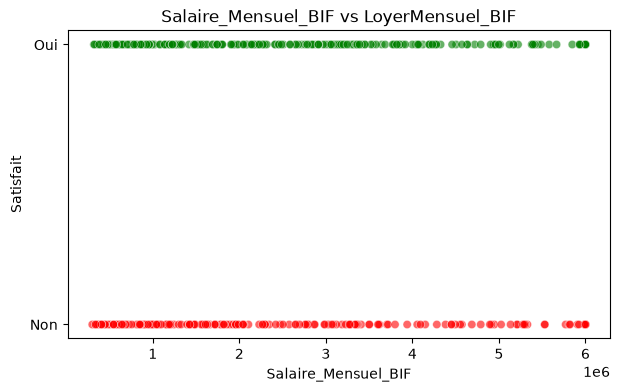

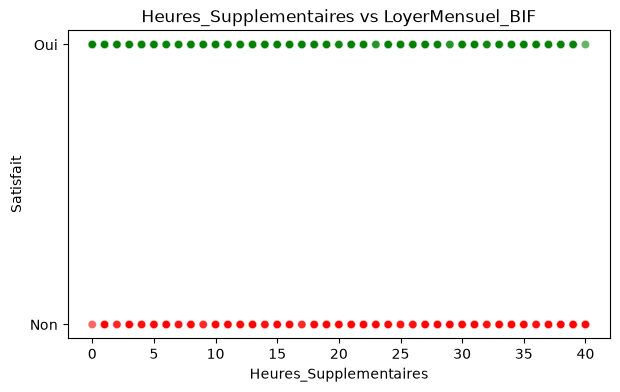

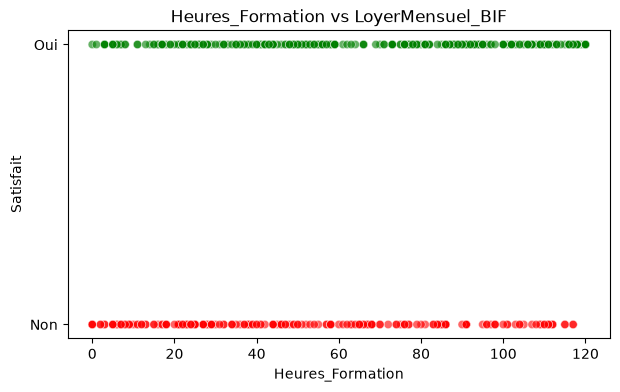

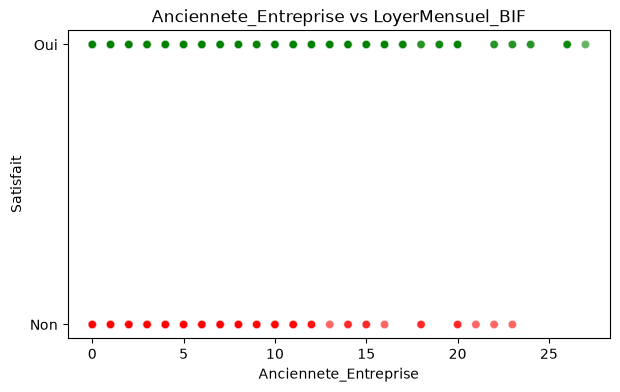

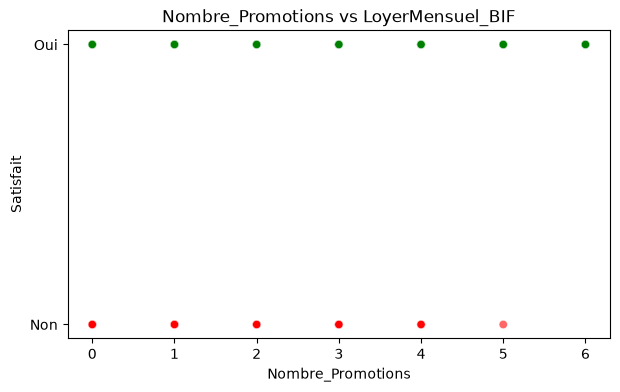

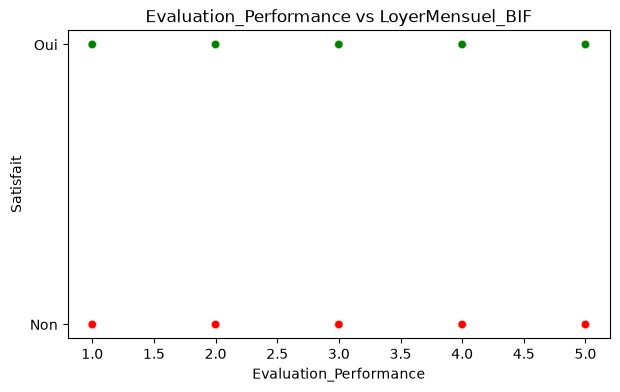

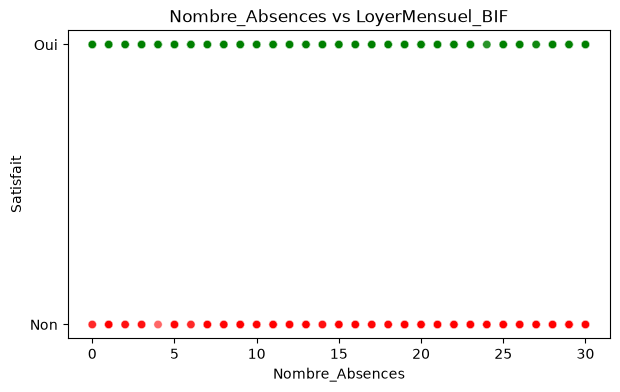

AttributeError: 'SeriesGroupBy' object has no attribute 'mode'

<Figure size 800x400 with 0 Axes>

In [33]:
# Scatter plots pour les variables numériques
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(
        color="indigo",
        data=df, 
        x=col,
        y="Satisfait",
        alpha=0.6, 
        hue="Satisfait",
        palette={"Oui": "green", "Non": "red"},
        legend=False
    )
    plt.title(f"{col} vs LoyerMensuel_BIF")
    plt.show()

# Boxplots pour les variables catégorielles
for col in category_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        y="Satisfait",
        palette="Pastel1",
        order=df.groupby(col)["Satisfait"]
        .mode()
        .sort_values(ascending=False)
        .index,
    )
    
    plt.title(f"Satisfait selon {col}")
    plt.xticks(rotation=45 if df[col].nunique() > 5 else 0)
    plt.show()